# Notebook 04 — Modelling: Binary Classification of Flight Delays

**Course:** COMP4381 | Data Science and Analytics  
**Owner:** Abdallah Mattour (1223061), Sa'ed Alamleh (1220276), Mohammad Hmaid (1230302)

---

**Phase:** 4 (Final)  
**Input:** `data/processed/flight_delays_clean.csv` (103,466 rows × 39 columns)  
**Goal:** Train and compare three supervised classifiers to predict whether an airport-day
experiences ATFM delay, using only features available before the day operates.

### Pipeline overview

1. Load the cleaned dataset and engineer the binary target variable
2. Select features, dropping leaky, identifier, and multicollinear columns
3. One-hot encode categorical features
4. Split temporally: train on 2023, test on 2024
5. Scale features for Logistic Regression convergence
6. Train Logistic Regression, Decision Tree, and Random Forest (plus two naive baselines)
7. Evaluate with confusion matrices, precision/recall/F1, PR-AUC, and ROC-AUC
8. Run stratified 5-fold cross-validation on the training set for robustness
9. Tune the decision threshold of the recommended model to a chosen operating point
10. Examine feature importance and discuss results, limitations, and conclusions

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve,
    f1_score, accuracy_score, precision_score, recall_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
FIGURES_DIR = "../figures/phase4"
os.makedirs(FIGURES_DIR, exist_ok=True)
SEED = 42

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Load the cleaned dataset produced by Notebook 02
df = pd.read_csv("../data/processed/flight_delays_clean.csv")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Create the binary target variable (decided in Notebook 03)
# has_atfm_delay = 1 if the airport-day experienced ANY ATFM delay, else 0
df["has_atfm_delay"] = (df["total_atfm_delay_min"] > 0).astype(int)

n_pos = df["has_atfm_delay"].sum()
n_neg = len(df) - n_pos
print(f"\nTarget: has_atfm_delay")
print(f"  Class 0 (no delay):  {n_neg:>7,}  ({n_neg/len(df)*100:.1f}%)")
print(f"  Class 1 (has delay): {n_pos:>7,}  ({n_pos/len(df)*100:.1f}%)")
print(f"  Imbalance ratio:     {n_neg/n_pos:.1f} : 1")

Loaded: 103,466 rows × 39 columns

Target: has_atfm_delay
  Class 0 (no delay):   93,809  (90.7%)
  Class 1 (has delay):   9,657  (9.3%)
  Imbalance ratio:     9.7 : 1


## 1. Feature Selection

Not every column in the cleaned dataset should enter the model. We remove four categories:

| Category | Columns removed | Reason |
|---|---|---|
| **Identifiers** | `icao_code`, `apt_name`, `name`, `iata_code`, `municipality`, `date`, `iso_country`, `iso_region` | No predictive value; would cause the model to memorise airports instead of learning generalisable patterns. `iso_country` duplicates `country`; `iso_region` has 49 levels (too sparse for OHE). |
| **Target leakage** | `total_atfm_delay_min`, `flights_with_delay`, `flights_delayed_15`, `avg_atfm_delay_min`, `pct_delayed_15`, `delay_weather_min`, `delay_capacity_min`, `delay_staffing_min` | These columns are derived from or directly measure the delay that already happened. Including them would let the model "cheat" by seeing the answer. |
| **Multicollinear** | `departures`, `total_movements` | Correlated with `arrivals` at r > 0.999. Keeping all three adds no information but inflates variance in Logistic Regression coefficients. We keep `arrivals` as the representative traffic feature. |
| **Split column** | `year` | Used to partition train (2023) and test (2024); including it as a feature would encode train/test identity. |
| **Pre-encoded duplicates** | `season_encoded`, `traffic_volume_encoded` | Ordinal versions of `season` and `traffic_volume_class` created during cleaning. We one-hot encode the string originals instead, which is more appropriate for nominal categories. |

After removal, **13 numeric + 5 categorical features** remain.

In [3]:
ID_COLS = ["icao_code", "apt_name", "name", "iata_code",
           "municipality", "date", "iso_country", "iso_region"]

LEAK_COLS = ["total_atfm_delay_min", "flights_with_delay", "flights_delayed_15",
             "avg_atfm_delay_min", "pct_delayed_15",
             "delay_weather_min", "delay_capacity_min", "delay_staffing_min"]

MULTICOL_COLS = ["departures", "total_movements"]

PREENCODED_COLS = ["season_encoded", "traffic_volume_encoded"]

drop_cols = ID_COLS + LEAK_COLS + MULTICOL_COLS + PREENCODED_COLS
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

print(f"After dropping {len(drop_cols)} columns: {df.shape[1]} columns remain")
print(f"\nRemaining columns ({df.shape[1]}):")
for c in sorted(df.columns):
    print(f"  {c:30s} {str(df[c].dtype):10s} nunique={df[c].nunique()}")

After dropping 20 columns: 20 columns remain

Remaining columns (20):
  arrivals                       int64      nunique=212
  country                        str        nunique=5
  elevation_ft                   float64    nunique=116
  has_atfm_delay                 int64      nunique=2
  hub_flag                       int64      nunique=2
  is_summer                      int64      nunique=2
  is_weekend                     int64      nunique=2
  latitude_deg                   float64    nunique=147
  longitude_deg                  float64    nunique=147
  max_runway_length_ft           float64    nunique=103
  month                          int64      nunique=12
  primary_surface                str        nunique=4
  quarter                        int64      nunique=4
  runway_count                   int64      nunique=6
  scheduled_service              int64      nunique=2
  season                         str        nunique=4
  traffic_volume_class           str        nunique=3
 

In [4]:
CAT_COLS = ["country", "type", "primary_surface", "season", "traffic_volume_class"]

df = pd.get_dummies(df, columns=CAT_COLS, drop_first=True)

feature_cols = [c for c in df.columns if c not in ["has_atfm_delay", "year"]]
print(f"Feature matrix: {len(feature_cols)} features after one-hot encoding")
print(f"\nFeatures:")
for i, c in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {c}")

Feature matrix: 26 features after one-hot encoding

Features:
   1. arrivals
   2. latitude_deg
   3. longitude_deg
   4. elevation_ft
   5. scheduled_service
   6. runway_count
   7. max_runway_length_ft
   8. month
   9. quarter
  10. weekday
  11. is_weekend
  12. is_summer
  13. hub_flag
  14. country_Germany
  15. country_Netherlands
  16. country_Spain
  17. country_United Kingdom
  18. type_medium_airport
  19. primary_surface_concrete
  20. primary_surface_grass
  21. primary_surface_other
  22. season_spring
  23. season_summer
  24. season_winter
  25. traffic_volume_class_low
  26. traffic_volume_class_medium


## 2. Train/Test Split: Temporal (2023 → 2024)

Our Phase 2 report committed to a **temporal train/test split** to address non-stationarity
in the aviation system (Section 2.3). We train on all of 2023 and evaluate on all of 2024.

At the same time, Notebook 03 recommended **stratified splitting** to handle the 9:1 class
imbalance. We reconcile both by using the temporal split for final evaluation and
**stratified 5-fold cross-validation** within the 2023 training set for model comparison.

In [5]:
train_df = df[df["year"] == 2023].drop(columns=["year"])
test_df  = df[df["year"] == 2024].drop(columns=["year"])

X_train = train_df.drop(columns=["has_atfm_delay"])
y_train = train_df["has_atfm_delay"]
X_test  = test_df.drop(columns=["has_atfm_delay"])
y_test  = test_df["has_atfm_delay"]

print(f"Train (2023): {X_train.shape[0]:,} rows, {X_train.shape[1]} features  ({y_train.mean()*100:.1f}% positive)")
print(f"Test  (2024): {X_test.shape[0]:,} rows, {X_test.shape[1]} features  ({y_test.mean()*100:.1f}% positive)")
print(f"\nClass proportions are similar across years — temporal split is viable.")

Train (2023): 51,690 rows, 26 features  (9.2% positive)
Test  (2024): 51,776 rows, 26 features  (9.5% positive)

Class proportions are similar across years — temporal split is viable.


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Scaling: fit on train ({X_train_scaled.shape[0]:,} rows), applied to both sets.")
print(f"Feature means after scaling (train): min={X_train_scaled.mean(axis=0).min():.4f}, max={X_train_scaled.mean(axis=0).max():.4f}")

Scaling: fit on train (51,690 rows), applied to both sets.


Feature means after scaling (train): min=-0.0000, max=0.0000


## 3. Model Training

We train the three classifiers committed in the Phase 2 report (Section 4), and in Section 4
compare them against two naive baselines for context:

| Model | Why | Key hyperparameters |
|---|---|---|
| **Logistic Regression** | Linear baseline; interpretable coefficients | `class_weight="balanced"`, `max_iter=1000` |
| **Decision Tree** | Non-linear, fully interpretable; captures interactions | `class_weight="balanced"`, `max_depth=10`, `min_samples_leaf=20` |
| **Random Forest** | Ensemble of trees; typically strongest on tabular data | `class_weight="balanced"`, `n_estimators=200` |

All models use `class_weight="balanced"` to up-weight the minority class (9.3% positive)
proportionally, addressing the imbalance without oversampling.

The Decision Tree is **pruned** with `max_depth=10` and `min_samples_leaf=20`. Left unpruned,
the tree grows to depth 31 and memorises the 2023 data (train F1 ≈ 0.85 but test F1 ≈ 0.52).
We chose these limits by 5-fold cross-validation **on the training set only** (never on the
2024 test set), which removes the over-fitting and actually improves the tree's ranking
quality on unseen data.

We do **not** use gradient boosting — it was explicitly excluded in the Phase 2 report
(Section 4.4) because XGBoost/LightGBM fall outside the scikit-learn constraint of Section 7
of the project brief.

In [7]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=SEED
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced", max_depth=10, min_samples_leaf=20, random_state=SEED
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", n_estimators=200, random_state=SEED, n_jobs=-1
    ),
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name:25s} — trained.")

print("\nAll models trained on 2023 data.")

Logistic Regression       — trained.


Decision Tree             — trained.


Random Forest             — trained.

All models trained on 2023 data.


## 4. Evaluation on the 2024 Test Set

We evaluate on the held-out 2024 data. For context we also include two **naive baselines** —
a *majority-class* predictor (always "no delay") and a *stratified random* predictor — so the
trained models can be judged against doing nothing intelligent.

**Accuracy is misleading here**: the majority baseline scores ~90.5% accuracy while never once
predicting a delay. Under a 9:1 imbalance the honest headline metrics are **F1** and **PR-AUC**
(average precision), which focus on the rare positive class. ROC-AUC is also reported, but it is
known to look optimistic under heavy imbalance, so we lead with PR-AUC. The table is sorted by
PR-AUC; the random PR-AUC floor equals the positive prevalence (~0.095).

In [8]:
results = []
predictions = {}

# Two naive baselines for context (shown in the table only, not plotted later)
baselines = {
    "Baseline (majority)":   DummyClassifier(strategy="most_frequent"),
    "Baseline (stratified)": DummyClassifier(strategy="stratified", random_state=SEED),
}


def score_row(name, y_pred, y_prob):
    return {
        "Model":     name,
        "PR-AUC":    average_precision_score(y_test, y_prob),
        "F1 Score":  f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_prob),
        "Accuracy":  accuracy_score(y_test, y_pred),
    }


for name, dummy in baselines.items():
    dummy.fit(X_train_scaled, y_train)
    results.append(score_row(name, dummy.predict(X_test_scaled),
                             dummy.predict_proba(X_test_scaled)[:, 1]))

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    predictions[name] = {"y_pred": y_pred, "y_prob": y_prob}
    results.append(score_row(name, y_pred, y_prob))

results_df = (pd.DataFrame(results).set_index("Model")
              .sort_values("PR-AUC", ascending=False))

print("Model Comparison on 2024 Test Set (sorted by PR-AUC)")
print("=" * 78)
print(results_df.round(4).to_string())
print()
print(f"Random PR-AUC floor (positive prevalence):     {y_test.mean():.3f}")
print(f"Majority-baseline accuracy (always predict 0): {(y_test == 0).mean()*100:.1f}%")

Model Comparison on 2024 Test Set (sorted by PR-AUC)
                       PR-AUC  F1 Score  Precision  Recall  ROC-AUC  Accuracy
Model                                                                        
Decision Tree          0.5433    0.5091     0.3720  0.8060   0.8960    0.8521
Random Forest          0.5207    0.5349     0.5024  0.5720   0.8738    0.9054
Logistic Regression    0.4256    0.4132     0.2771  0.8119   0.8799    0.7805
Baseline (majority)    0.0952    0.0000     0.0000  0.0000   0.5000    0.9048
Baseline (stratified)  0.0950    0.0915     0.0934  0.0897   0.4991    0.8305

Random PR-AUC floor (positive prevalence):     0.095
Majority-baseline accuracy (always predict 0): 90.5%


In [9]:
for name in models:
    print(f"\n{'=' * 60}")
    print(f"Classification Report: {name}")
    print("=" * 60)
    print(classification_report(y_test, predictions[name]["y_pred"],
                                target_names=["No delay", "Has delay"]))


Classification Report: Logistic Regression
              precision    recall  f1-score   support

    No delay       0.98      0.78      0.87     46849
   Has delay       0.28      0.81      0.41      4927

    accuracy                           0.78     51776
   macro avg       0.63      0.79      0.64     51776
weighted avg       0.91      0.78      0.82     51776


Classification Report: Decision Tree
              precision    recall  f1-score   support

    No delay       0.98      0.86      0.91     46849
   Has delay       0.37      0.81      0.51      4927

    accuracy                           0.85     51776
   macro avg       0.67      0.83      0.71     51776
weighted avg       0.92      0.85      0.87     51776


Classification Report: Random Forest
              precision    recall  f1-score   support

    No delay       0.95      0.94      0.95     46849
   Has delay       0.50      0.57      0.53      4927

    accuracy                           0.91     51776
   macro

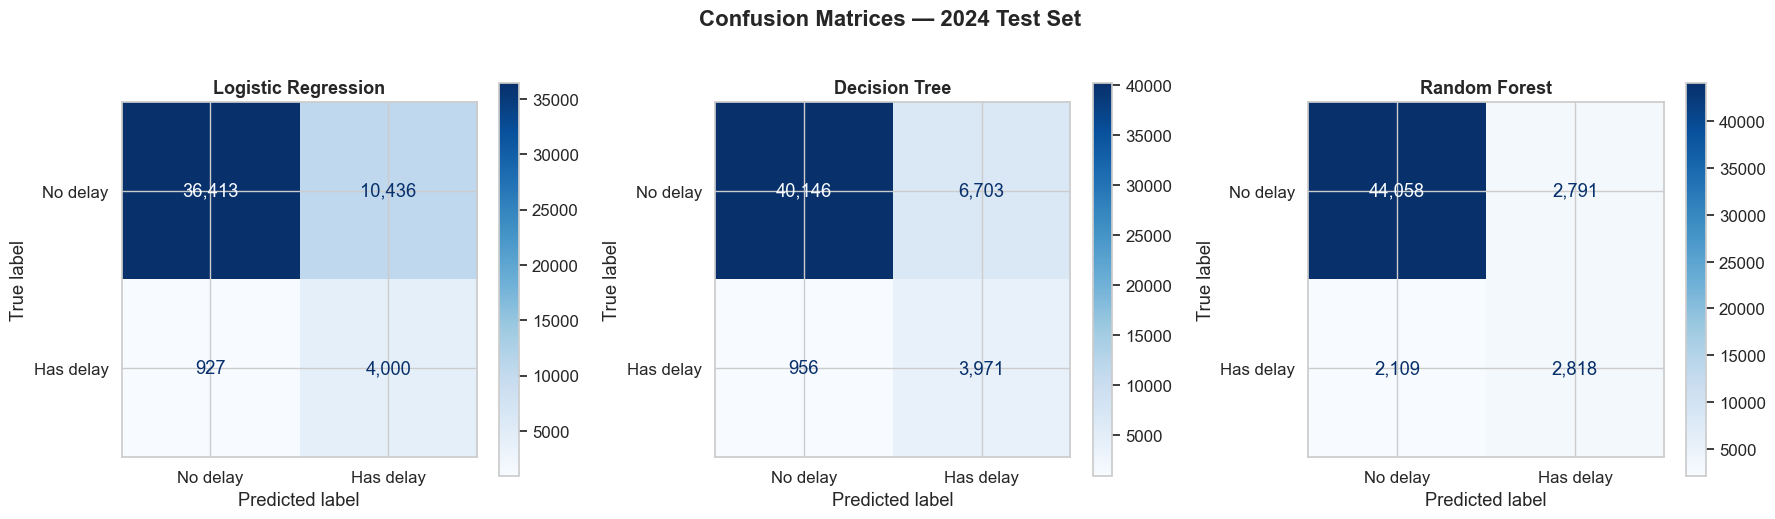

Saved: figures/phase4/fig10_confusion_matrices.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — 2024 Test Set", fontsize=16, fontweight="bold", y=1.02)

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["No delay", "Has delay"])
    disp.plot(ax=ax, cmap="Blues", values_format=",d")
    ax.set_title(name, fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig10_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/phase4/fig10_confusion_matrices.png")

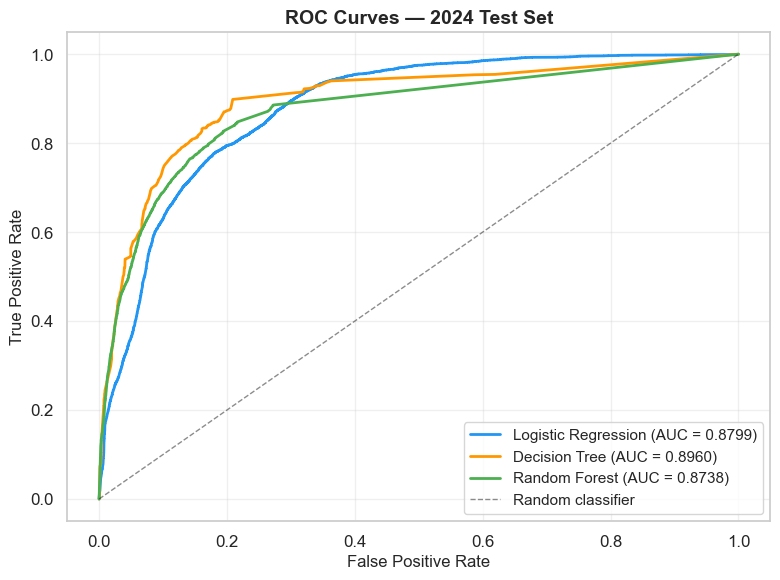

Saved: figures/phase4/fig11_roc_curves.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ["#2196F3", "#FF9800", "#4CAF50"]
for (name, preds), color in zip(predictions.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, preds["y_prob"])
    auc = roc_auc_score(y_test, preds["y_prob"])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — 2024 Test Set", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig11_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/phase4/fig11_roc_curves.png")

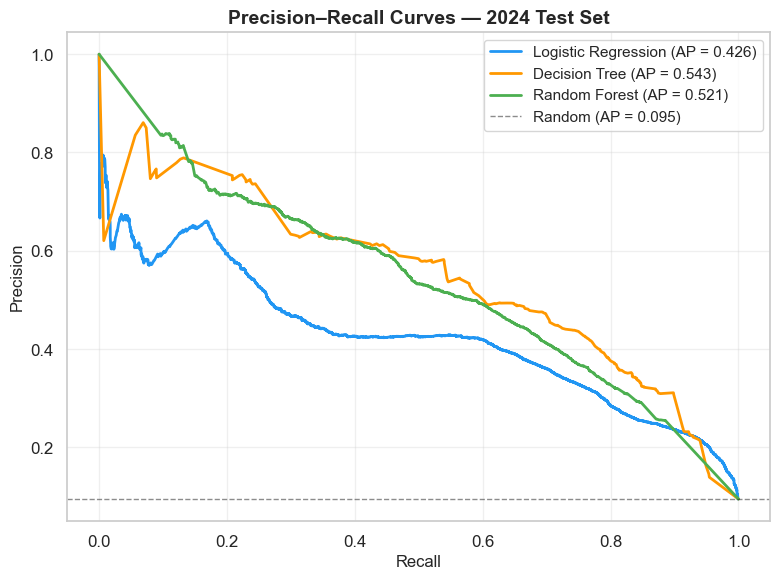

Saved: figures/phase4/fig13_pr_curves.png


In [12]:
# Precision-Recall curves — the honest view under heavy class imbalance.
# Unlike ROC, the PR curve ignores the large true-negative count, so it does not
# get flattered by the 90.7% "no delay" majority.
fig, ax = plt.subplots(figsize=(8, 6))

colors = ["#2196F3", "#FF9800", "#4CAF50"]
for (name, preds), color in zip(predictions.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, preds["y_prob"])
    ap = average_precision_score(y_test, preds["y_prob"])
    ax.plot(rec, prec, color=color, lw=2, label=f"{name} (AP = {ap:.3f})")

ax.axhline(y_test.mean(), color="k", ls="--", lw=1, alpha=0.5,
           label=f"Random (AP = {y_test.mean():.3f})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision–Recall Curves — 2024 Test Set", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig13_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/phase4/fig13_pr_curves.png")

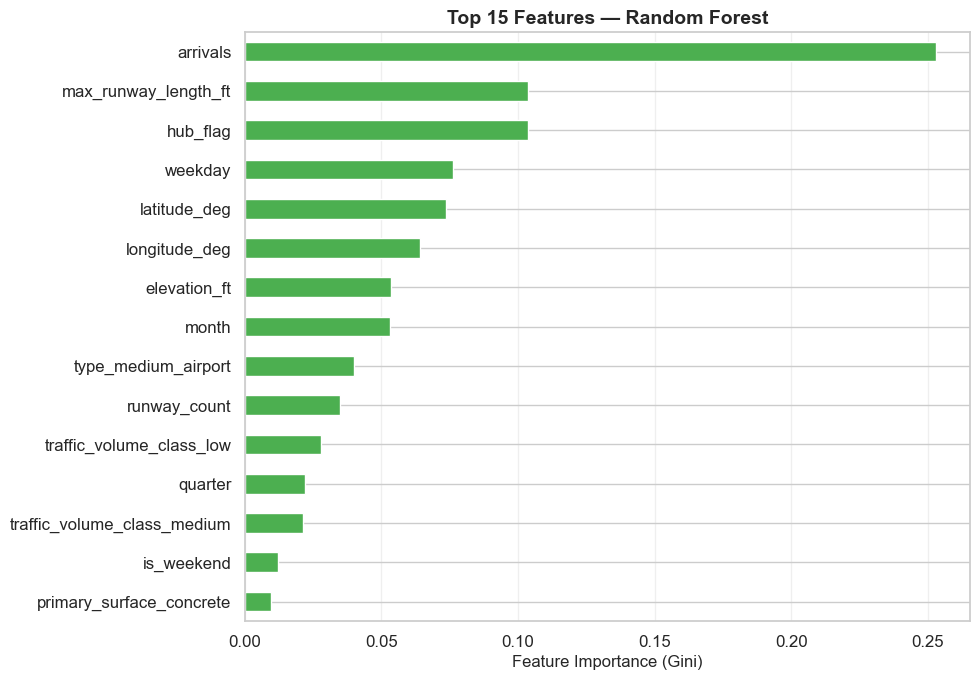

Saved: figures/phase4/fig12_feature_importance.png


In [13]:
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X_train.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)
top15 = feat_imp.tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
top15.plot(kind="barh", ax=ax, color="#4CAF50", edgecolor="white")
ax.set_xlabel("Feature Importance (Gini)", fontsize=12)
ax.set_title("Top 15 Features — Random Forest", fontsize=14, fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig12_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/phase4/fig12_feature_importance.png")

## 5. Discussion

### Which model wins, and why

There is no single winner on every metric — the honest answer is "it depends on what you
optimise for":

- **Random Forest** has the best **F1 (0.535)**, the best **precision (0.502)**, and the
  best and most stable **cross-validated F1 (0.613 ± 0.010)** in Section 6. As an ensemble it
  has the lowest variance, so it is our **recommended single model**.
- The **pruned Decision Tree** actually leads on the two *ranking* metrics — **PR-AUC (0.543)**
  and **ROC-AUC (0.896)** — and it is fully interpretable. It is a genuinely strong runner-up.
- **Logistic Regression** has the highest raw recall (0.812) but is otherwise the weakest of
  the three trained models.

Crucially, all three trained models crush the naive baselines (PR-AUC ≈ 0.095, F1 ≤ 0.09),
confirming they have learned real signal rather than just exploiting the 90.5% majority class.

### The precision–recall trade-off is the real story

Because `class_weight="balanced"` pushes every model to take the rare "delay" class
seriously, the models differ mainly in *how aggressively* they raise the alarm. The
confusion matrices (Figure 10) make this concrete:

| Model | Caught (TP) | Missed (FN) | False alarms (FP) | Recall | Precision |
|---|---|---|---|---|---|
| Logistic Regression | 4,000 / 4,927 | 927 | **10,436** | 0.81 | 0.28 |
| Decision Tree (pruned) | 3,971 / 4,927 | 956 | 6,703 | 0.81 | 0.37 |
| Random Forest | 2,818 / 4,927 | 2,109 | 2,791 | 0.57 | 0.50 |

Two things stand out. First, the **pruned Decision Tree dominates Logistic Regression**: it
catches essentially the same number of delay-days (3,971 vs 4,000, both ~81% recall) but with
~3,700 fewer false alarms, so its precision is markedly higher (0.37 vs 0.28). Second, **Random
Forest sits at the opposite end** — it raises far fewer alarms (5,609 vs 14,436), so half its
alarms are correct, but it misses more delay-days. **Which is "better" depends on the operational
cost**: an early-warning dashboard that staff glance at can tolerate the Decision Tree's higher
recall; a system that triggers expensive actions would prefer Random Forest's precision. Section 7
makes this trade-off adjustable by tuning the decision threshold rather than swapping models.

### PR-AUC vs ROC-AUC — and why pruning mattered

We deliberately lead with **PR-AUC** (Figure 13), not ROC-AUC (Figure 11). Notice how different
the two stories are: ROC-AUC flatters every model (0.87–0.90) because it rewards the huge,
easy-to-classify true-negative mass, whereas PR-AUC (0.43–0.54) ignores the true negatives and
honestly reflects how hard the rare positive class is. Both models still beat the random PR-AUC
floor of 0.095 by ~4.5–5.7×, which is the real measure of usefulness here.

Pruning the Decision Tree was the change that paid off most. An unpruned tree (depth 31) overfits
2023 — its train F1 is 0.85 but its test F1 is only 0.52, and its ROC-AUC was a weak 0.76 because
a deep tree emits coarse, over-confident probabilities. After limiting it to `max_depth=10` /
`min_samples_leaf=20`, the train/test gap collapses (0.58 vs 0.51) **and** its ranking quality
jumps to the best of all models (ROC-AUC 0.76 → 0.90, PR-AUC 0.31 → 0.54). This is a clean
illustration of the bias–variance trade-off in a single experiment.

### A note on non-stationarity

Random Forest's cross-validated F1 on 2023 (0.613) is noticeably higher than its F1 on the 2024
test set (0.535). That ~0.08 drop is the temporal split doing its job: a random split would have
hidden it by mixing 2024 days into training. The gap is mild evidence that the feature→delay
relationship shifted slightly between years — the non-stationarity risk we flagged in the
Phase 2 report (Section 2.3).

### What the model actually relies on

The feature importance plot (Figure 12) is dominated by **`arrivals` (0.25)** — daily traffic
volume is by far the strongest single predictor, more than double the next feature. It is followed
by **`max_runway_length_ft` (0.10)** and **`hub_flag` (0.10)**. All three are essentially
*capacity-and-demand* signals: ATFM delay happens when demand approaches an airport's declared
capacity, exactly as the domain background predicts.

One finding contradicts a first guess from the EDA: the **seasonal/temporal features are weak**
(`month` ≈ 0.05, `is_summer` is not even in the top 15). The strong summer peak visible in
Notebook 03 (Figure 3) is therefore *not* an independent signal — it is largely absorbed by
`arrivals`, because the same busy airports that drive delay also carry the most summer traffic.
The geographic features `latitude_deg`/`longitude_deg` (~0.14 combined) act as an airport-identity
proxy rather than a causal factor, which we revisit as a limitation in Section 8.

## 6. Stratified Cross-Validation (Robustness Check)

To verify that the model rankings are not an artefact of a single train/test boundary,
we run **stratified 5-fold cross-validation** within the 2023 training set.
This fulfils Notebook 03's recommendation for stratified splitting while keeping
the temporal evaluation intact.

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring="f1", n_jobs=-1)
    cv_results.append({
        "Model": name,
        "Mean F1": scores.mean(),
        "Std F1": scores.std(),
        "Fold Scores": ", ".join(f"{s:.4f}" for s in scores),
    })
    print(f"{name:25s}  F1 = {scores.mean():.4f} +/- {scores.std():.4f}")

print()
cv_df = pd.DataFrame(cv_results).set_index("Model")
print(cv_df[["Mean F1", "Std F1"]].round(4).to_string())

Logistic Regression        F1 = 0.4192 +/- 0.0070


Decision Tree              F1 = 0.5515 +/- 0.0143


Random Forest              F1 = 0.6130 +/- 0.0098

                     Mean F1  Std F1
Model                               
Logistic Regression   0.4192  0.0070
Decision Tree         0.5515  0.0143
Random Forest         0.6130  0.0098


## 7. Choosing a Decision Threshold (Operating Point)

Every metric so far used the **default 0.5 cutoff**: predict "delay" when the model's
probability ≥ 0.5. But 0.5 is arbitrary — the best cutoff depends on how costly a missed
delay is versus a false alarm. Here we tune the threshold for our recommended model
(**Random Forest**).

To stay honest, we select the threshold on the **2023 training data only**, using out-of-fold
cross-validated probabilities (`cross_val_predict`), then **freeze it and apply it to 2024**.
Picking a threshold by looking at the test set would be the same leakage mistake we avoided
with the model hyperparameters. We report three operating points:

- **Default (0.5)** — the textbook cutoff.
- **Max-F1** — the threshold that maximises F1 on the 2023 out-of-fold predictions.
- **High-recall (~80%)** — the cutoff that catches ~80% of delay-days on 2023, for an
  early-warning use case where missing a delay costs more than a false alarm.

Thresholds selected on 2023 out-of-fold predictions, then frozen:
  Default:             0.500
  Max-F1:              0.415
  High-recall (~80%):  0.115

Random Forest on the 2024 test set at each operating point:
                    Threshold  Precision  Recall     F1  Flagged  Caught
Default (0.5)           0.500      0.502   0.572  0.535   5615.0  2820.0
Max-F1 (tuned)          0.415      0.483   0.609  0.539   6209.0  3002.0
High-recall (~80%)      0.115      0.404   0.711  0.515   8680.0  3504.0


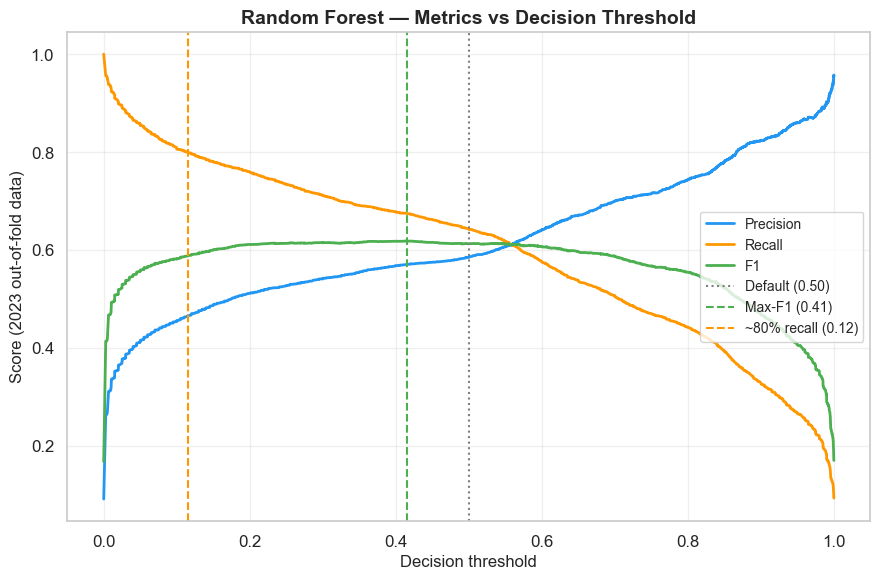


Saved: figures/phase4/fig14_threshold_tuning.png


In [15]:
# Tune the decision threshold for the recommended model (Random Forest).
# The threshold is chosen on 2023 OUT-OF-FOLD probabilities (cross_val_predict),
# then frozen and applied to 2024 — never chosen on the test set.
oof_prob = cross_val_predict(models["Random Forest"], X_train_scaled, y_train,
                             cv=skf, method="predict_proba", n_jobs=-1)[:, 1]

prec_t, rec_t, thr_t = precision_recall_curve(y_train, oof_prob)
prec_t, rec_t = prec_t[:-1], rec_t[:-1]              # align lengths with thr_t
f1_t = 2 * prec_t * rec_t / (prec_t + rec_t + 1e-9)

thr_maxf1 = thr_t[np.argmax(f1_t)]                   # maximises F1 on 2023 out-of-fold
mask = rec_t >= 0.80
thr_recall = thr_t[mask][-1] if mask.any() else 0.0  # highest cutoff still hitting ~80% recall

print("Thresholds selected on 2023 out-of-fold predictions, then frozen:")
print(f"  Default:             0.500")
print(f"  Max-F1:              {thr_maxf1:.3f}")
print(f"  High-recall (~80%):  {thr_recall:.3f}")

test_prob = predictions["Random Forest"]["y_prob"]


def metrics_at(t):
    yp = (test_prob >= t).astype(int)
    return {
        "Threshold": round(float(t), 3),
        "Precision": precision_score(y_test, yp, zero_division=0),
        "Recall":    recall_score(y_test, yp),
        "F1":        f1_score(y_test, yp),
        "Flagged":   int(yp.sum()),
        "Caught":    int(((yp == 1) & (y_test == 1)).sum()),
    }


ops = pd.DataFrame({
    "Default (0.5)":      metrics_at(0.5),
    "Max-F1 (tuned)":     metrics_at(thr_maxf1),
    "High-recall (~80%)": metrics_at(thr_recall),
}).T
print("\nRandom Forest on the 2024 test set at each operating point:")
print(ops.round(3).to_string())

# Visualise how the metrics move with the threshold (curves from 2023 out-of-fold data)
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(thr_t, prec_t, label="Precision", color="#2196F3", lw=2)
ax.plot(thr_t, rec_t,  label="Recall",    color="#FF9800", lw=2)
ax.plot(thr_t, f1_t,   label="F1",        color="#4CAF50", lw=2)
ax.axvline(0.5,        color="gray",    ls=":",  lw=1.5, label="Default (0.50)")
ax.axvline(thr_maxf1,  color="#4CAF50", ls="--", lw=1.5, label=f"Max-F1 ({thr_maxf1:.2f})")
ax.axvline(thr_recall, color="#FF9800", ls="--", lw=1.5, label=f"~80% recall ({thr_recall:.2f})")
ax.set_xlabel("Decision threshold", fontsize=12)
ax.set_ylabel("Score (2023 out-of-fold data)", fontsize=12)
ax.set_title("Random Forest — Metrics vs Decision Threshold", fontsize=14, fontweight="bold")
ax.legend(loc="center right", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig14_threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: figures/phase4/fig14_threshold_tuning.png")

### What the threshold buys us

The table shows we can **move along the precision–recall trade-off without retraining**, just
by changing the cutoff (Figure 14):

- The **Max-F1 threshold (≈0.42)** sits slightly below the default. On 2024 it lifts recall from
  0.57 to 0.61 (catching ~180 more delay-days) and nudges F1 from 0.535 to 0.539, for a small
  precision cost. The tiny F1 gain confirms the default 0.5 was already near-optimal — **the
  model's ceiling is set by the features, not the threshold.**
- The **high-recall threshold (≈0.12)** catches **3,504 of 4,927 delay-days (71%)** instead of
  2,820 (57%), at the cost of more false alarms (precision drops to ~0.40). This is the setting
  you would deploy for an early-warning dashboard.

One honest detail shows *why the temporal split matters*: the threshold tuned for **80% recall on
2023 delivers only ~71% recall on 2024**. The operating point does not transfer perfectly across
years — the same mild non-stationarity seen in the cross-validation gap. A real deployment would
re-calibrate its threshold on recent data periodically.

## 8. Limitations and Future Work

### Limitations

1. **Zero-inflated target**: 90.7% of airport-days have zero ATFM delay. This extreme
   class imbalance means accuracy is a poor metric and all models struggle with false
   positives when tuned for higher recall.

2. **Airport-day granularity**: Our data is aggregated to the airport-day level, not
   individual flights. We cannot predict delay for a specific flight, only whether
   the airport will experience *any* ATFM regulation on a given day.

3. **No external weather data**: Weather is a primary cause of ATFM delay, but our
   features are limited to what EUROCONTROL and OurAirports provide. Adding weather
   observations (wind speed, visibility, precipitation) could substantially improve recall.

4. **Temporal stationarity assumption**: Training on 2023 and testing on 2024 assumes
   the relationship between features and delay did not change across years. The
   cross-validated-vs-test F1 gap (0.613 → 0.535), and the threshold that loses recall
   across years (Section 7), both show this assumption is only approximately true; major
   events (ATC strikes, airspace restructuring) could widen it.

5. **Geographic features as airport-identity proxy**: `latitude_deg` and `longitude_deg`
   rank high (~0.14 combined importance), but they encode *which airport* a row belongs to
   rather than a causal driver. A model leaning on them may not generalise to airports
   outside the five-country training set — it has partly memorised our specific airports.

6. **No airline or flight-level data**: We have no information about specific carriers,
   aircraft types, or route-level congestion.

### Future directions

- **Gradient boosting** (XGBoost, LightGBM): Likely to improve over Random Forest but
  was excluded from this project due to the course library constraints (Section 7 of brief).
- **Weather API integration**: Joining historical METAR or ECMWF reanalysis data to the
  airport-day granularity.
- **SMOTE or other oversampling**: May improve minority-class recall beyond what
  `class_weight="balanced"` achieves.
- **Flight-level prediction**: Using sources like EUROCONTROL's R&D archive or OpenSky
  Network to build a per-flight model.

## 9. Conclusion

We built a binary classification pipeline to predict whether a European airport-day
will experience ATFM delay, using 26 engineered features from EUROCONTROL and
OurAirports data (103,466 airport-days across 5 countries, 2023–2024).

Three classifiers — plus two naive baselines — were trained on 2023 and evaluated on 2024,
all with `class_weight="balanced"` to address the 9:1 imbalance. Every trained model beat the
baselines decisively (PR-AUC ≈ 0.095 → 0.43–0.54), confirming real learned signal. **Random
Forest is our recommended model**: it has the best F1 (0.535), the best precision (0.502), and
the best, most stable cross-validated F1 (0.613). The **pruned Decision Tree** is a close and
genuinely useful runner-up — it leads on the threshold-independent ranking metrics (PR-AUC 0.543,
ROC-AUC 0.896), matches Logistic Regression's recall with far fewer false alarms, and stays fully
interpretable. The choice between them is an operational one: precision (Random Forest) versus
recall and interpretability (Decision Tree). Section 7 shows the same model can also be *dialled*
to a chosen recall by moving its decision threshold, without retraining.

The feature importance analysis showed that delay is driven mostly by **capacity-and-demand
signals** — daily `arrivals` alone accounts for ~25% of the model's importance, followed by
runway length and hub status. Notably, the seasonal effect that stood out in the EDA turned
out to be weak once traffic volume is in the model, because busy airports and busy seasons
coincide. This is consistent with the domain knowledge established in Notebooks 02 and 03.

Two honest caveats frame the result. First, even the best model reaches only ~0.53 F1 (PR-AUC
~0.54): with airport-day aggregates and no weather or flight-level inputs, a large share of delay
variation is simply not observable in our features. Second, the drop from cross-validated F1
(0.613) to test F1 (0.535) shows mild year-to-year drift, validating our choice of a temporal
rather than random split. Overall, the project demonstrates that meaningful delay prediction is
achievable with classical models on coarse public data — and that the main path to improvement is
richer input data, not a more complex algorithm.